In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [7]:
# CSV 檔案所在資料夾
input_folder = Path("/home/kaiwi/FAM/Dataset/")

# 輸出資料夾
output_folder = Path("/home/kaiwi/FAM/Dataset/")
output_folder.mkdir(exist_ok=True)

# x, y 欄位名稱
x_col = "x"
y_col = "y"

# 想保留的 x, y 範圍
x_min, x_max = -5, 5
y_min, y_max = -12, 12

# 是否把所有曲線畫在同一張圖
plot_together = False

In [8]:

csv_files = list(input_folder.glob("*.csv"))
if len(csv_files) == 0:
    raise FileNotFoundError(f"在 {input_folder} 找不到任何 CSV 檔")

if plot_together:
    plt.figure(figsize=(8, 6))

df = pd.read_csv(input_folder / "MFIS_t_10.csv", header=None, names=["x", "y"])

# 刪除 x, y 範圍外的資料
df_filtered = df[
    (df[x_col] >= x_min) & (df[x_col] <= x_max) &
    (df[y_col] >= y_min) & (df[y_col] <= y_max)
]

df_filtered = df_filtered[
    (df[x_col] >= 3.7) | (df[x_col] <= 3.5) |
    (df[y_col] >= -0.76) | (df[y_col] <= -1.2)
]

# 輸出處理後 CSV
output_path = output_folder / "MFIS_t_10.csv"
df_filtered.to_csv(output_path, index=False, header=False)

print(f"MFIS_t_10.csv: {len(df)} -> {len(df_filtered)} points")

MFIS_t_10.csv: 180 -> 180 points


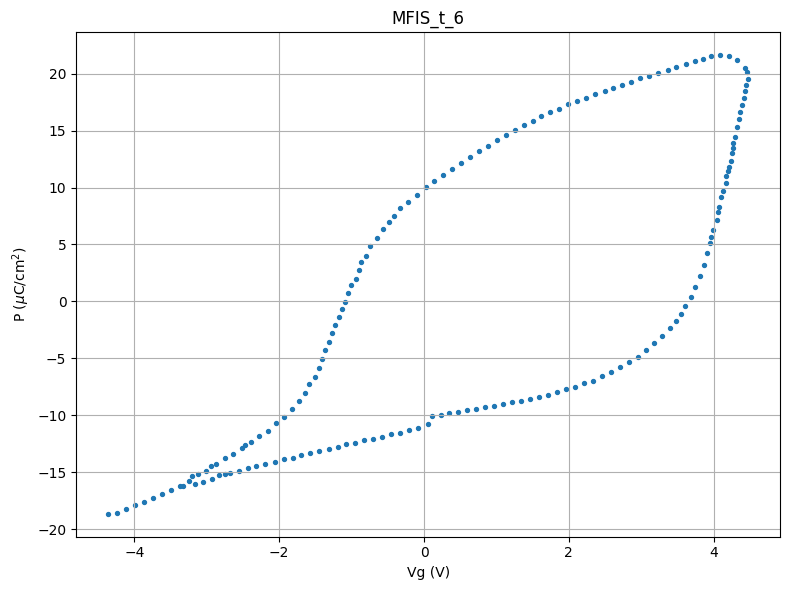

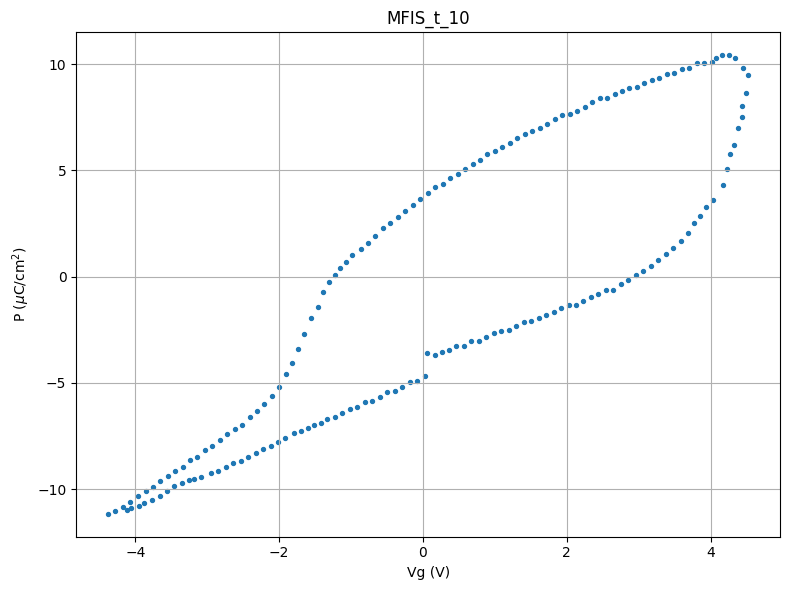

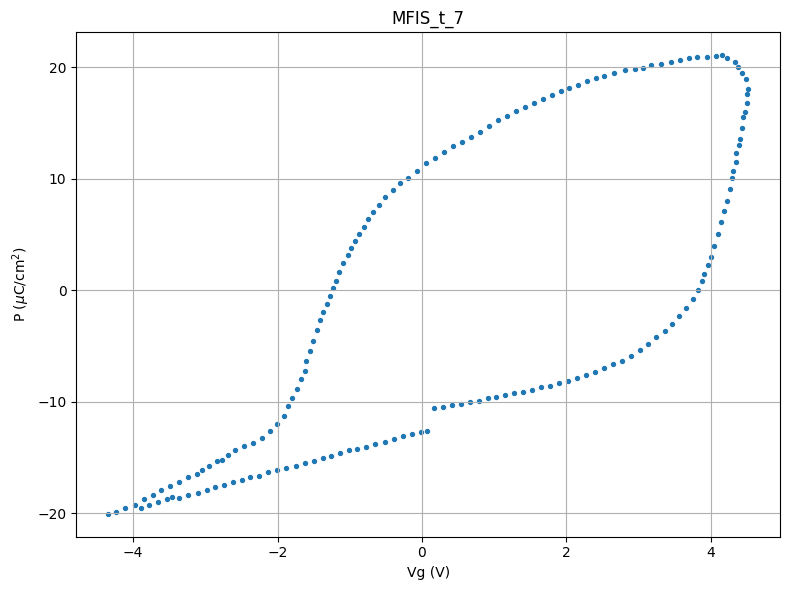

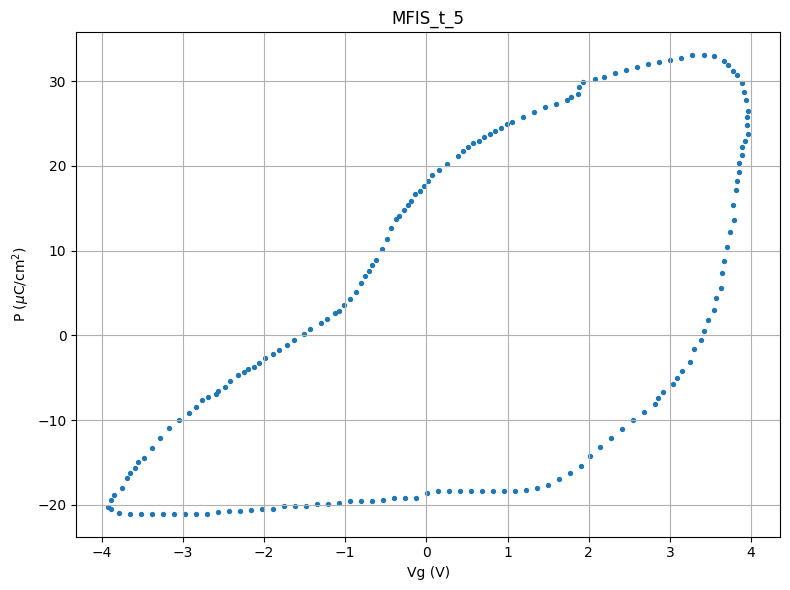

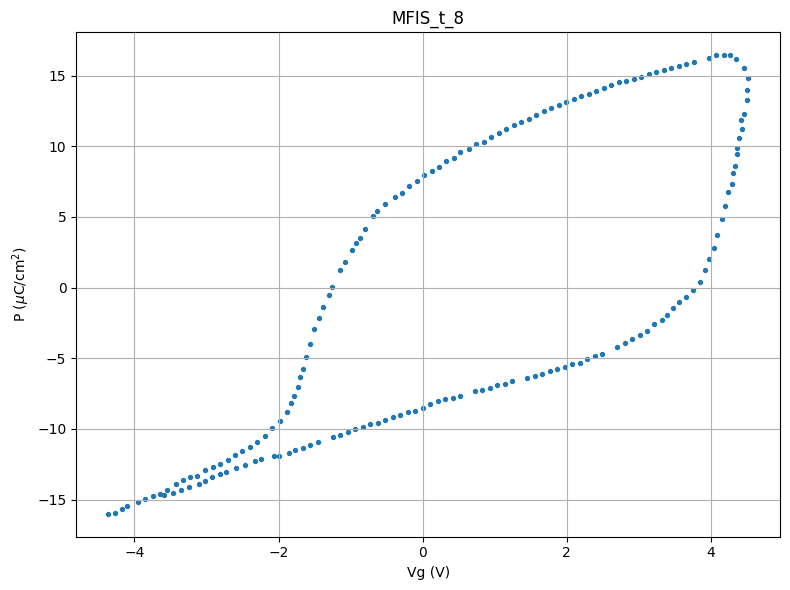

In [9]:
for csv_file in csv_files:
    df = pd.read_csv(csv_file, header=None, names=["x", "y"])

    # 檢查欄位是否存在
    if x_col not in df.columns or y_col not in df.columns:
        print(f"跳過 {csv_file.name}，因為找不到 {x_col} 或 {y_col} 欄位")
        continue

    # 畫圖（不要連線：改用 scatter）
    if plot_together:
        plt.scatter(df[x_col], df[y_col], s=8, label=csv_file.stem)  # s: 點大小
    else:
        plt.figure(figsize=(8, 6))
        plt.scatter(df[x_col], df[y_col], s=8)
        plt.xlabel("Vg (V)")
        plt.ylabel(r"P ($\mu$C/cm$^2$)")  # cm^2 用上標；μ 用 mathtext
        plt.title(csv_file.stem)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(output_folder / f"{csv_file.stem}_plot.png", dpi=300)
        plt.show()

# 如果畫在同一張圖
if plot_together:
    plt.xlabel(x_col)
    plt.ylabel(r"P ($\mu$C/cm$^2$)")
    plt.title("Filtered XY plots")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_folder / "all_filtered_xy_plot.png", dpi=300)
    plt.show()